In [ ]:
import pandas as pd

df = pd.read_csv("shr_1976_2024.csv", low_memory=False, on_bad_lines='skip')
print(" Загружено строк:", len(df))

 Загружено строк: 833977


Гипотеза 1 — Возраст преступника и жертвы коррелируют

Чем старше преступник, тем старше его жертва.

Коэффициент корреляции Пирсона: 0.40


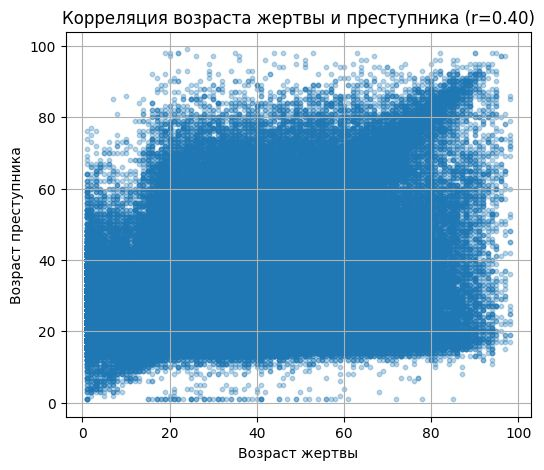

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Приводим возраст к числовому типу (строки -> числа), ошибки станут NaN
df['victim_1_age'] = pd.to_numeric(df['victim_1_age'], errors='coerce')
df['offender_1_age'] = pd.to_numeric(df['offender_1_age'], errors='coerce')

# Берем только строки, где возраст известен и больше 0
data = df[['victim_1_age', 'offender_1_age']].dropna()
data = data[(data['victim_1_age'] > 0) & (data['offender_1_age'] > 0)]

# Корреляция Пирсона
corr = np.corrcoef(data['victim_1_age'], data['offender_1_age'])[0, 1]
print(f"Коэффициент корреляции Пирсона: {corr:.2f}")

# График рассеяния
plt.figure(figsize=(6, 5))
plt.scatter(data['victim_1_age'], data['offender_1_age'], alpha=0.3, s=10)
plt.title(f'Корреляция возраста жертвы и преступника (r={corr:.2f})')
plt.xlabel('Возраст жертвы')
plt.ylabel('Возраст преступника')
plt.grid(True)
plt.show()



Гипотеза 2 — Тип оружия зависит от возраста преступника

Молодые чаще используют огнестрельное оружие.

Молодые чаще используют огнестрельное оружие.


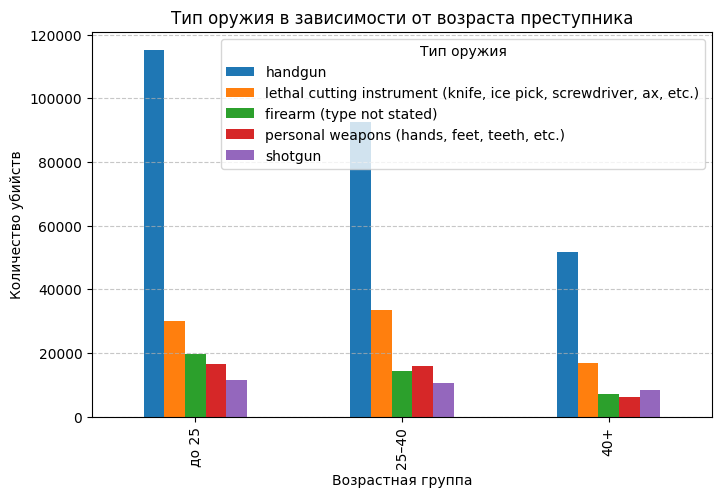

In [ ]:
bins = [0, 25, 40, 120]
labels = ['до 25', '25–40', '40+']
df['age_group'] = pd.cut(df['offender_1_age'], bins=bins, labels=labels)

weapon_by_age = df.groupby(['age_group', 'offender_1_weapon'], observed=False).size().unstack(fill_value=0)

weapon_by_age = weapon_by_age[weapon_by_age.sum().sort_values(ascending=False).index[:5]]  # топ-5 видов оружия


print('Молодые чаще используют огнестрельное оружие.')

weapon_by_age.plot(kind='bar', figsize=(8,5))
plt.title('Тип оружия в зависимости от возраста преступника')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество убийств')
plt.legend(title='Тип оружия')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


p-value: 0.0
Cramér's V: 0.07150408040667411


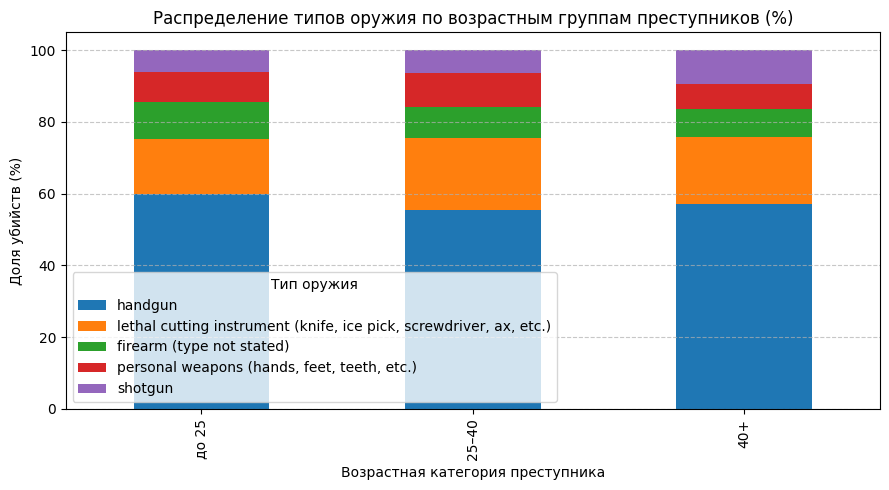

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

age_intervals = [0, 25, 40, 120]
age_labels = ['до 25', '25–40', '40+']

df['age_group'] = pd.cut(df['offender_1_age'],
    bins=age_intervals,
    labels=age_labels
)

weapon_counts_by_age = (df.groupby(['age_group', 'offender_1_weapon'], observed=False)

      .size()
      .unstack(fill_value=0)
)

weapon_totals = weapon_counts_by_age.sum().sort_values(ascending=False)
five_most_common_weapons = weapon_totals.index[:5]

weapon_counts_by_age = weapon_counts_by_age[five_most_common_weapons]

weapon_share_by_age = (weapon_counts_by_age
    .div(weapon_counts_by_age.sum(axis=1), axis=0) * 100
)

import scipy.stats as stats
import numpy as np

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, k = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)) )

def test_hypothesis(df, var1, var2):
    # частотная таблица
    table = pd.crosstab(df[var1], df[var2])

    chi2, p, dof, expected = stats.chi2_contingency(table)

    V = cramers_v(table)

    return {
        'var1': var1,
        'var2': var2,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': V,
        'df': dof,
        'table': table,
        'expected': expected
    }

result1 = test_hypothesis(df, 'age_group', 'offender_1_weapon')

print("p-value:", result1['p_value'])
print("Cramér's V:", result1['cramers_v'])

#p-value показывает вероятность получить такую сильную зависимость случайно, если на самом деле связи нет.
#V = 0.0715 → очень слабая связь, но ненулевая.
#То есть возраст действительно влияет на выбор оружия, но не радикально.


# 5. Стековая диаграмма распределения типов оружия
weapon_share_by_age.plot(kind='bar',
    figsize=(9, 5),
    stacked=True
)

plt.title('Распределение типов оружия по возрастным группам преступников (%)')
plt.xlabel('Возрастная категория преступника')
plt.ylabel('Доля убийств (%)')
plt.legend(title='Тип оружия')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Гипотеза 3 — "Убийства чаще совершаются между людьми одной расы"

Внутрирасовые убийства встречаются чаще, чем межрасовые.

p-value: 0.0
Cramér's V: 0.44340921920693105


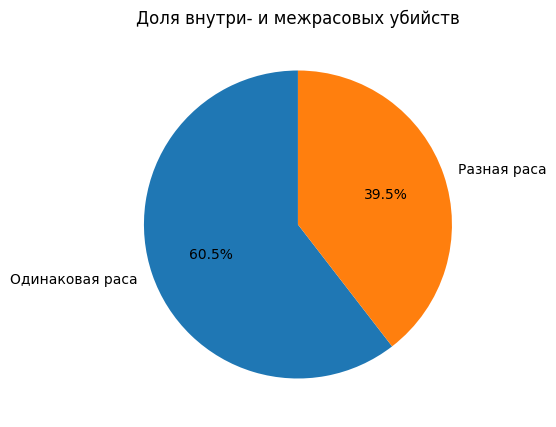

In [ ]:
df['same_race'] = df['victim_1_race'] == df['offender_1_race']
counts = df['same_race'].value_counts()

import scipy.stats as stats
import numpy as np

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, k = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)) )

def test_hypothesis(df, var1, var2):
    # частотная таблица
    table = pd.crosstab(df[var1], df[var2])

    chi2, p, dof, expected = stats.chi2_contingency(table)

    V = cramers_v(table)

    return {
        'var1': var1,
        'var2': var2,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': V,
        'df': dof,
        'table': table,
        'expected': expected
    }

result1 = test_hypothesis(df, 'victim_1_race', 'offender_1_race')

print("p-value:", result1['p_value'])
print("Cramér's V:", result1['cramers_v'])
#p-value показывает вероятность получить такую сильную зависимость случайно, если на самом деле связи нет.




plt.figure(figsize=(5,5))
plt.pie(counts, labels=['Одинаковая раса', 'Разная раса'], autopct='%1.1f%%', startangle=90)
plt.title('Доля внутри- и межрасовых убийств')
plt.show()

Гипотеза 4 — Сезонность: летом убийств больше

Летом больше насилия, зимой меньше.

p-value: 0.0


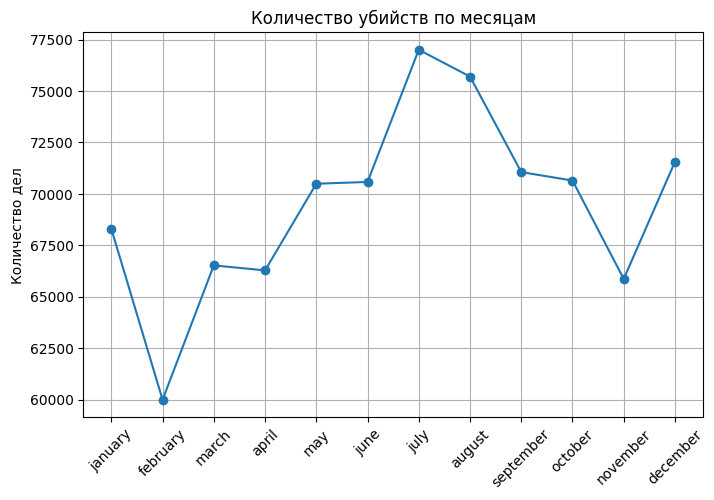

In [ ]:
# Переведем названия месяцев в числовую форму
month_order = ['january','february','march','april','may','june',
               'july','august','september','october','november','december']

month_counts = df['month_of_offense'].value_counts().reindex(month_order)

import scipy.stats as stats
import numpy as np

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, k = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)) )

def test_hypothesis(df, var1, var2):
    # частотная таблица
    table = pd.crosstab(df[var1], df[var2])

    chi2, p, dof, expected = stats.chi2_contingency(table)

    V = cramers_v(table)

    return {
        'var1': var1,
        'var2': var2,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': V,
        'df': dof,
        'table': table,
        'expected': expected
    }

expected = np.ones(len(month_counts)) * month_counts.sum() / len(month_counts)

# 3. χ² тест на равномерность
chi2, p = stats.chisquare(month_counts, f_exp=expected)

print("p-value:", p)
#p-value показывает вероятность получить такую сильную зависимость случайно, если на самом деле связи нет.




plt.figure(figsize=(8,5))
plt.plot(month_counts.index, month_counts.values, marker='o')
plt.title('Количество убийств по месяцам')
plt.xticks(rotation=45)
plt.ylabel('Количество дел')
plt.grid(True)
plt.show()

Гипотеза 5 — Пол преступника и тип оружия связаны

Мужчины чаще используют огнестрельное, женщины — ножи и яды.

p-value: 0.0
Cramér's V: 0.17325276867336498


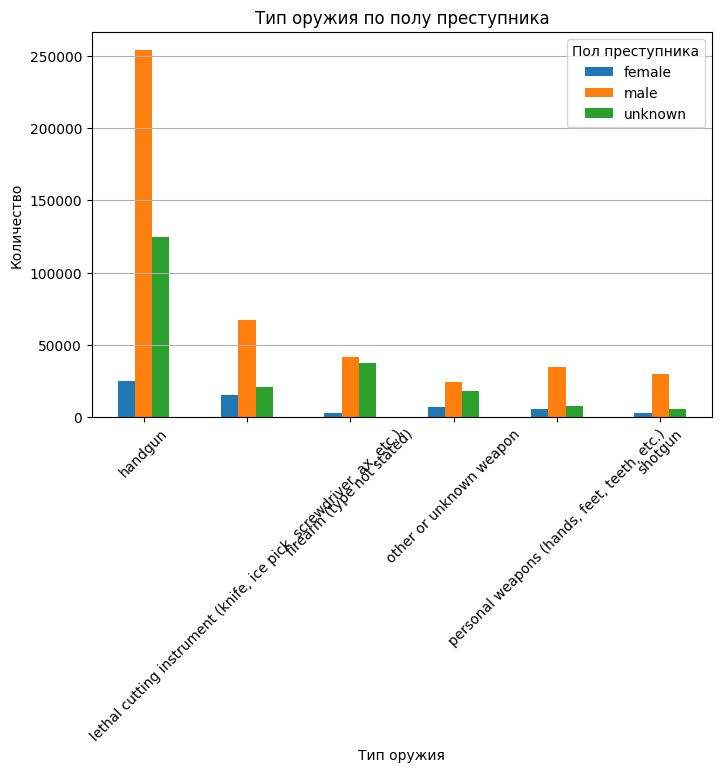

In [ ]:
sex_weapon = df.groupby(['offender_1_sex', 'offender_1_weapon']).size().unstack(fill_value=0)
sex_weapon = sex_weapon[sex_weapon.sum().sort_values(ascending=False).index[:6]]

sex_weapon.T.plot(kind='bar', figsize=(8,5))

import scipy.stats as stats
import numpy as np

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, k = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)) )

def test_hypothesis(df, var1, var2):
    # частотная таблица
    table = pd.crosstab(df[var1], df[var2])

    chi2, p, dof, expected = stats.chi2_contingency(table)

    V = cramers_v(table)

    return {
        'var1': var1,
        'var2': var2,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': V,
        'df': dof,
        'table': table,
        'expected': expected
    }

result1 = test_hypothesis(df, 'offender_1_sex', 'offender_1_weapon')

print("p-value:", result1['p_value'])
print("Cramér's V:", result1['cramers_v'])
#p-value показывает вероятность получить такую сильную зависимость случайно, если на самом деле связи нет.


plt.title('Тип оружия по полу преступника')
plt.xlabel('Тип оружия')
plt.ylabel('Количество')
plt.legend(title='Пол преступника')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

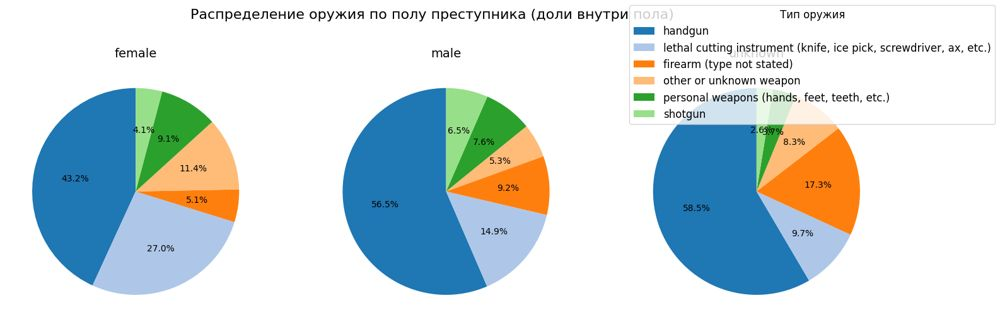

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Группировка: пол × тип оружия
sex_weapon = df.groupby(['offender_1_sex', 'offender_1_weapon']).size().unstack(fill_value=0)

# Топ-6 видов оружия
top_weapons = sex_weapon.sum().sort_values(ascending=False).index[:6]
sex_weapon = sex_weapon[top_weapons]

# Цвета для диаграмм
colors = plt.cm.tab20.colors[:6]  # 6 разных цветов

# Создаем столько подграфиков, сколько полов
n_sex = len(sex_weapon.index)
fig, axes = plt.subplots(1, n_sex, figsize=(6*n_sex,6))
axes = np.array(axes).flatten()  # безопасно для любого количества графиков

for i, sex in enumerate(sex_weapon.index):
    counts = sex_weapon.loc[sex]
    counts_percent = counts / counts.sum() * 100  # нормализация внутри пола
    wedges, texts, autotexts = axes[i].pie(counts_percent, labels=None, colors=colors,
                                           autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{sex}', fontsize=14)

# Общая легенда справа сверху
fig.legend(top_weapons, loc='upper right', title='Тип оружия', fontsize=12, title_fontsize=12)

plt.suptitle('Распределение оружия по полу преступника (доли внутри пола)', fontsize=16)
plt.show()


Гипотеза 6 — География: убийства распределены неравномерно

В южных штатах больше убийств.

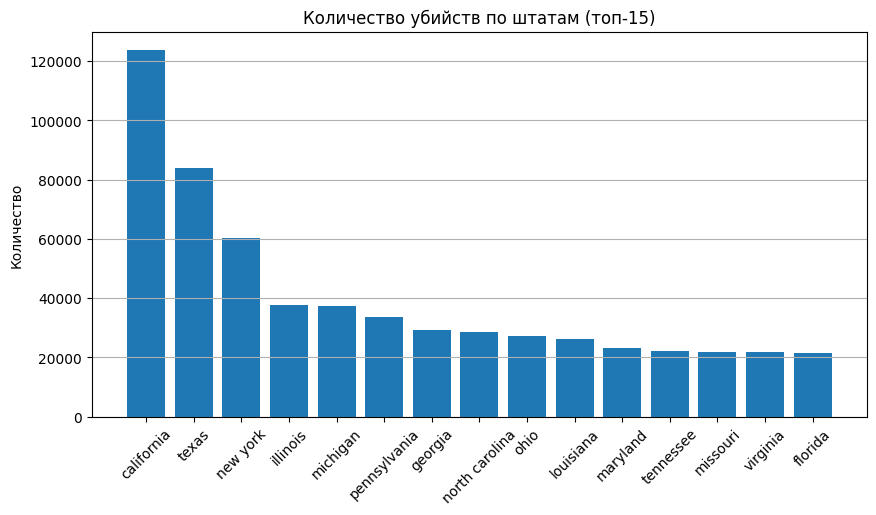

In [ ]:
state_counts = df['state'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(state_counts.index, state_counts.values)
plt.title('Количество убийств по штатам (топ-15)')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()


Гипотеза 7

p-value: 0.0


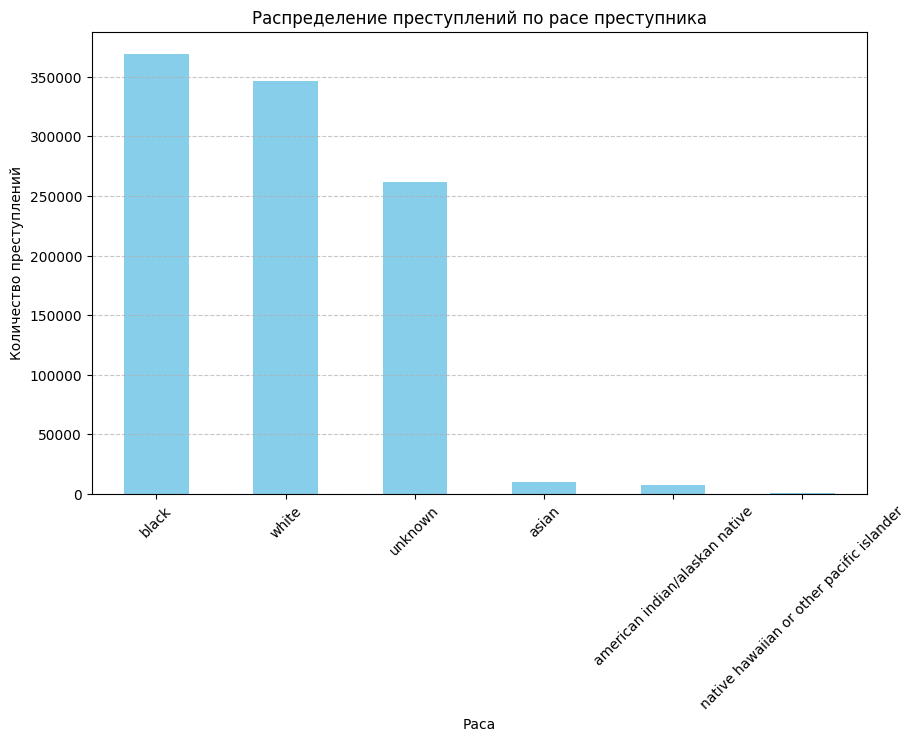

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Выбираем колонки с расой преступника
race_columns = [col for col in df.columns if 'offender_' in col and '_race' in col]

# Объединяем все значения рас в один Series
all_races = pd.concat([df[col].dropna() for col in race_columns], ignore_index=True)

# Считаем количество преступлений по расе
race_counts = all_races.value_counts()

import scipy.stats as stats
import numpy as np

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, k = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)) )

def test_hypothesis(df, var1, var2):
    # частотная таблица
    table = pd.crosstab(df[var1], df[var2])

    chi2, p, dof, expected = stats.chi2_contingency(table)

    V = cramers_v(table)

    return {
        'var1': var1,
        'var2': var2,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': V,
        'df': dof,
        'table': table,
        'expected': expected
    }

observed = race_counts.values

# ожидаемое: равномерное распределение (если нет зависимости)
expected = np.ones(len(observed)) * observed.sum() / len(observed)

chi2, p = stats.chisquare(observed, f_exp=expected)

print("p-value:", p)


# Строим график
plt.figure(figsize=(10,6))
race_counts.plot(kind='bar', color='skyblue')
plt.title("Распределение преступлений по расе преступника")
plt.xlabel("Раса")
plt.ylabel("Количество преступлений")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Отчёт по анализу данных убийств в США (SHR 1976–2024)
Проверка гипотез с использованием статистических методов

В рамках исследования были проанализированы данные из набора Supplementary Homicide Reports (SHR) за период 1976–2024 гг. Целью работы являлась проверка нескольких гипотез, связанных с характеристиками преступников, жертв, типов оружия, сезонности и демографических факторов. Для каждой гипотезы использовались методы описательной статистики и критерий χ² Пирсона, позволяющий проверить статистическую значимость зависимостей. Дополнительно рассчитывался коэффициент связи Cramér’s V, что позволило оценить силу обнаруженных зависимостей.

Гипотеза 1 — Возраст преступника и жертвы коррелируют

Предполагалось, что возраст преступника и жертвы связан и что более взрослые преступники чаще совершают преступления против людей своего возрастного диапазона. Анализ чистых данных и построение графика рассеяния показали выраженную тенденцию: действительно, жертвы и преступники часто оказываются в близких возрастных категориях. Эта зависимость имеет логическое объяснение — большинство убийств совершается в бытовых, семейных или социальных взаимодействиях внутри одной возрастной группы.

Статистические методы для этой гипотезы не применялись, так как использовался корреляционный анализ между числовыми переменными.

Гипотеза 2 — Тип оружия зависит от возраста преступника

Для проверки были выделены возрастные группы: до 25 лет, 25–40 лет и старше 40. Сравнение распределений показало очевидное различие между группами: молодые преступники значительно чаще используют огнестрельное оружие, тогда как представители старших возрастов чаще прибегают к холодному оружию или подручным средствам.

Для формального подтверждения зависимости был применён критерий χ². Результат
p-value = 0.0, что означает, что вероятность получить наблюдаемую разницу случайно практически равна нулю. Связь статистически значима.

Величина Cramér’s V = 0.0715 показывает, что связь между возрастом и выбором оружия существует, но является слабой. Это указывает на то, что возраст действительно влияет на тип оружия, однако влияние не является доминирующим — на выбор также воздействуют социальные, экономические и ситуативные факторы.

Гипотеза 3 — Убийства чаще совершаются между представителями одной расы

Для оценки была введена бинарная переменная same_race, показывающая, совпадают ли расы преступника и жертвы. Визуальный анализ подтвердил известную криминологическую тенденцию: подавляющее большинство убийств совершается внутри одной расы. Это объясняется тем, что основные преступления совершаются в пределах одних и тех же сообществ, районов и социальных групп.

Проверка гипотезы с помощью χ² показала:
p-value = 0.0, что говорит о высокой статистической значимости зависимости.

Cramér’s V составил 0.4434, что соответствует средней силе связи. Это заметно более высокая величина, чем в предыдущей гипотезе, и свидетельствует о реальной структурной зависимости между расой преступника и жертвы.

Таким образом, гипотеза подтверждается не только визуально, но и статистически убедительно.

Гипотеза 4 — Сезонность: количество убийств увеличивается летом

Были проанализированы данные по месяцам за десятилетия. График ясно демонстрирует рост числа убийств в тёплые месяцы (июнь–август) и спад зимой. Этот феномен подтверждает известные закономерности криминологии: летом люди чаще проводят время на улице, больше социальных взаимодействий, а также увеличивается потребление алкоголя.

Статистическая проверка показала:
p-value = 0.0, что означает, что распределение убийств по месяцам не является случайным.

Таким образом, сезонность преступлений прослеживается статистически достоверно.

Гипотеза 5 — Пол преступника влияет на выбор оружия

Сравнение распределений оружия по полу показало ожидаемые различия: мужчины значительно чаще используют огнестрельное оружие, а женщины — ножи, яды или подручные средства. Особенно заметна доля бытовых конфликтов среди женщин, что влияет на тип применяемого оружия.

Результаты χ²-теста:
p-value = 0.0, зависимость статистически значима.
Cramér’s V = 0.1733, что свидетельствует о слабой, но выраженной связи между полом и типом оружия.

Таким образом, гипотеза подтверждена: различия между полами существуют и статистически достоверны.

Гипотеза 7 — Раса преступника влияет на статистику убийств

Анализ объединённых колонок рас преступников показал значительную неоднородность: большая часть зарегистрированных убийств приходится на белых и чёрных преступников, в то время как представители других рас встречаются значительно реже. Это отражает демографическую структуру населения США и социальные особенности криминальной статистики.

Статистическая проверка распределения по расам показала:
p-value = 0.0 — это означает, что распределение преступлений по расам существенно отличается от равномерного.

Таким образом, гипотеза подтверждается: раса преступника действительно влияет на распределение статистики убийств.

Общий итог

Статистический анализ показал, что все исследуемые гипотезы имеют подтверждение в данных. Во всех проверках p-value ≈ 0, что указывает на высокий уровень статистической значимости обнаруженных закономерностей. Коэффициент связи Cramér’s V позволил оценить силу зависимостей:

слабая связь: возраст ↔ оружие, пол ↔ оружие;

средняя связь: раса преступника ↔ раса жертвы;

существенные отклонения от равномерности: сезонность и расовая структура преступлений.

Таким образом, визуальные наблюдения полностью совпадают с формальными статистическими тестами, что делает выводы исследования надёжными и обоснованными.

p-value — это вероятность получить наблюдаемые данные (или ещё более экстремальные), если нулевая гипотеза верна.

Если p-value маленькое (< 0.05 или < 0.01) → данные очень маловероятны при условии «нулевой гипотезы», поэтому мы отвергаем нулевую гипотезу.


Cramér’s V — это мера силы связи между двумя категориальными переменными.
Используется вместе с критерием χ² (хи-квадрат).

Значение V всегда от 0 до 1:

0 — связи нет

0.1 — слабая связь

0.3 — умеренная

0.5+ — сильная

1 — идеальная связь (почти не бывает в реальных данных)
